In [15]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split

from braindecode.models import EEGNet
import copy
import random
import pandas as pd
from tqdm import notebook
import tqdm
from pathlib import Path
import numpy as np
import scipy


torch.cuda.is_available()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.cuda.get_device_name(0)

'NVIDIA RTX 3000 Ada Generation Laptop GPU'

In [7]:
!nvidia-smi

Mon Mar 16 23:46:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.211.01             Driver Version: 570.211.01     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX 3000 Ada Gene...    Off |   00000000:01:00.0 Off |                  Off |
| N/A   44C    P8              5W /   35W |     276MiB /   8188MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Utilities

In [8]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from cross_subject_utils import (
    plot_learning_curves,
    evaluate,
    load_data_from_users,
    get_windows,
)

In [9]:
from cca import CCA, reference_matrix

In [10]:
def train(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs=100,
    device=0,
    save_path="best_model.pth",
):
    best_val_accuracy = -float("inf")
    model.to(device)
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    for epoch in tqdm.notebook.tqdm(range(num_epochs)):
        # Training Phase
        model.train()
        running_loss = 0.0
        train_correct = 0
        train_total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

            # eval train
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        train_accuracy = train_correct / train_total
        avg_train_loss = running_loss / len(train_loader)

        # eval validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.inference_mode():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                # val accuracy
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_accuracy = val_correct / val_total
        avg_val_loss = val_loss / len(val_loader)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        # Save if best vall acc
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_model = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), save_path)
            # print(f"Best model saved with accuracy: {best_val_accuracy:.4f}")

        print(
            f"Epoch {epoch + 1}/{num_epochs}: "
            f"Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, "
            f"Val Loss: {avg_val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}"
        )
    plot_learning_curves(train_losses, val_losses, train_accuracies, val_accuracies)
    model.load_state_dict(best_model)
    return model

# Cross Subject

In [11]:
freq_phase_path = (
    "/home/mateuschinelatto/Experiments/data/benchmark/Freq_Phase.mat"
)
freq_phase = scipy.io.loadmat(freq_phase_path)
frequencias = np.round(freq_phase["freqs"], 2).ravel()
fases = freq_phase["phases"]

# Parâmetros do pré-processamento
sample_rate = 250
filter_order = 10
freq_cut_high = 50
freq_cut_low = 6
delay = 160

# Parâmetros do CCA
num_harmonica = 3
inform_fase = 0

# Parâmetros de janelas e sessões
tamanho_da_janela_seg = 1
tamanho_da_janela = int(np.ceil(tamanho_da_janela_seg * sample_rate))

occipital_electrodes = np.array([47, 53, 54, 55, 56, 57, 60, 61, 62])
frequencias_desejadas = frequencias[:8]
indices = [np.where(frequencias == freq)[0][0] for freq in frequencias_desejadas]

# Usuários
# users = list(range(1, 36))  # Usuários de 1 a 35
users = list(range(1, 11))  # Usuários de 1 a 10

epochs = 1000
exp_dir = Path(
    f"10_8/CCA_eegnet_nb/{len(users)}_users_{len(frequencias_desejadas)}_freqs_{tamanho_da_janela_seg}_s/"
)

In [12]:
print("Usuários de interesse:", users)
print(f"Frequencies used: {frequencias_desejadas}")
print(f"Frequencies indices: {indices}")

Usuários de interesse: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Frequencies used: [ 8.  9. 10. 11. 12. 13. 14. 15.]
Frequencies indices: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


In [13]:
all_data = load_data_from_users(
    dataset_path="/home/mateuschinelatto/Experiments/data/benchmark/",
    users=users,
    visual_delay=delay,
    filter_bandpass=True,
    sample_rate=sample_rate,
    freq_cut_low=freq_cut_low,
    freq_cut_high=freq_cut_high,
    filter_order=filter_order,
)

Carregando dados dos usuários: 100%|██████████| 10/10 [00:31<00:00,  3.16s/it]


# Hard code

Processando Usuário 1
Train Users: [2, 3, 4, 5, 6, 7, 8, 9, 10]
0
Generating reference for frequency index 0, frequency 8.0 Hz
Y_train shape after freq 8.0 Hz: (13500, 6, 8)
Y_test shape after freq 8.0 Hz: (1500, 6, 8)
1
Generating reference for frequency index 1, frequency 9.0 Hz
Y_train shape after freq 9.0 Hz: (13500, 6, 8)
Y_test shape after freq 9.0 Hz: (1500, 6, 8)
2
Generating reference for frequency index 2, frequency 10.0 Hz
Y_train shape after freq 10.0 Hz: (13500, 6, 8)
Y_test shape after freq 10.0 Hz: (1500, 6, 8)
3
Generating reference for frequency index 3, frequency 11.0 Hz
Y_train shape after freq 11.0 Hz: (13500, 6, 8)
Y_test shape after freq 11.0 Hz: (1500, 6, 8)
4
Generating reference for frequency index 4, frequency 12.0 Hz
Y_train shape after freq 12.0 Hz: (13500, 6, 8)
Y_test shape after freq 12.0 Hz: (1500, 6, 8)
5
Generating reference for frequency index 5, frequency 13.0 Hz
Y_train shape after freq 13.0 Hz: (13500, 6, 8)
Y_test shape after freq 13.0 Hz: (1500, 

/tmp/ipykernel_359974/3403985805.py:175: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_treino = torch.tensor(rotulos_treinamento, dtype=torch.long).to(device)
/tmp/ipykernel_359974/3403985805.py:176: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_teste = torch.tensor(rotulos_teste, dtype=torch.long).to(device)


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1/1000: Train Loss: 2.0773, Train Accuracy: 0.1417, Val Loss: 2.0781, Val Accuracy: 0.1692
Epoch 2/1000: Train Loss: 2.0103, Train Accuracy: 0.2725, Val Loss: 2.0760, Val Accuracy: 0.1231
Epoch 3/1000: Train Loss: 1.9300, Train Accuracy: 0.4087, Val Loss: 2.0714, Val Accuracy: 0.1538
Epoch 4/1000: Train Loss: 1.8327, Train Accuracy: 0.4823, Val Loss: 2.0610, Val Accuracy: 0.1846
Epoch 5/1000: Train Loss: 1.7335, Train Accuracy: 0.5123, Val Loss: 2.0438, Val Accuracy: 0.2308
Epoch 6/1000: Train Loss: 1.5963, Train Accuracy: 0.5831, Val Loss: 2.0149, Val Accuracy: 0.2769
Epoch 7/1000: Train Loss: 1.4990, Train Accuracy: 0.5749, Val Loss: 1.9721, Val Accuracy: 0.3692
Epoch 8/1000: Train Loss: 1.4059, Train Accuracy: 0.5395, Val Loss: 1.9153, Val Accuracy: 0.5231
Epoch 9/1000: Train Loss: 1.2826, Train Accuracy: 0.6049, Val Loss: 1.8516, Val Accuracy: 0.5538
Epoch 10/1000: Train Loss: 1.2246, Train Accuracy: 0.6240, Val Loss: 1.7934, Val Accuracy: 0.5692
Epoch 11/1000: Train Loss: 1.

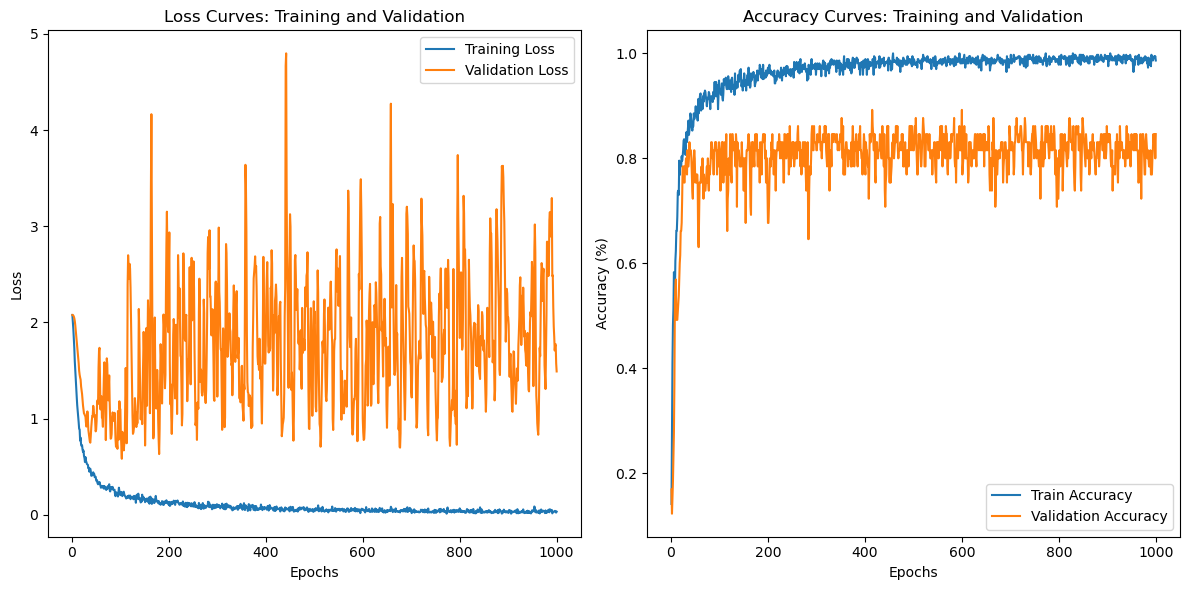

Test User 1 Finished: Accuracy=0.7708, Recall=0.7708, F1=0.7760
--------------------------------------------------
Processando Usuário 2
Train Users: [1, 3, 4, 5, 6, 7, 8, 9, 10]
0
Generating reference for frequency index 0, frequency 8.0 Hz
Y_train shape after freq 8.0 Hz: (13500, 6, 8)
Y_test shape after freq 8.0 Hz: (1500, 6, 8)
1
Generating reference for frequency index 1, frequency 9.0 Hz
Y_train shape after freq 9.0 Hz: (13500, 6, 8)
Y_test shape after freq 9.0 Hz: (1500, 6, 8)
2
Generating reference for frequency index 2, frequency 10.0 Hz
Y_train shape after freq 10.0 Hz: (13500, 6, 8)
Y_test shape after freq 10.0 Hz: (1500, 6, 8)
3
Generating reference for frequency index 3, frequency 11.0 Hz
Y_train shape after freq 11.0 Hz: (13500, 6, 8)
Y_test shape after freq 11.0 Hz: (1500, 6, 8)
4
Generating reference for frequency index 4, frequency 12.0 Hz
Y_train shape after freq 12.0 Hz: (13500, 6, 8)
Y_test shape after freq 12.0 Hz: (1500, 6, 8)
5
Generating reference for frequency 

/tmp/ipykernel_359974/3403985805.py:175: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_treino = torch.tensor(rotulos_treinamento, dtype=torch.long).to(device)
/tmp/ipykernel_359974/3403985805.py:176: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_teste = torch.tensor(rotulos_teste, dtype=torch.long).to(device)


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1/1000: Train Loss: 2.0519, Train Accuracy: 0.1826, Val Loss: 2.0759, Val Accuracy: 0.2000
Epoch 2/1000: Train Loss: 1.9581, Train Accuracy: 0.3406, Val Loss: 2.0704, Val Accuracy: 0.4000
Epoch 3/1000: Train Loss: 1.8744, Train Accuracy: 0.4414, Val Loss: 2.0593, Val Accuracy: 0.5077
Epoch 4/1000: Train Loss: 1.7827, Train Accuracy: 0.4741, Val Loss: 2.0400, Val Accuracy: 0.4923
Epoch 5/1000: Train Loss: 1.6647, Train Accuracy: 0.5695, Val Loss: 2.0090, Val Accuracy: 0.5538
Epoch 6/1000: Train Loss: 1.5039, Train Accuracy: 0.6349, Val Loss: 1.9578, Val Accuracy: 0.5538
Epoch 7/1000: Train Loss: 1.3821, Train Accuracy: 0.6376, Val Loss: 1.8884, Val Accuracy: 0.5538
Epoch 8/1000: Train Loss: 1.2630, Train Accuracy: 0.6431, Val Loss: 1.8110, Val Accuracy: 0.5692
Epoch 9/1000: Train Loss: 1.1540, Train Accuracy: 0.6703, Val Loss: 1.7326, Val Accuracy: 0.6154
Epoch 10/1000: Train Loss: 1.0519, Train Accuracy: 0.6812, Val Loss: 1.6570, Val Accuracy: 0.6769
Epoch 11/1000: Train Loss: 0.

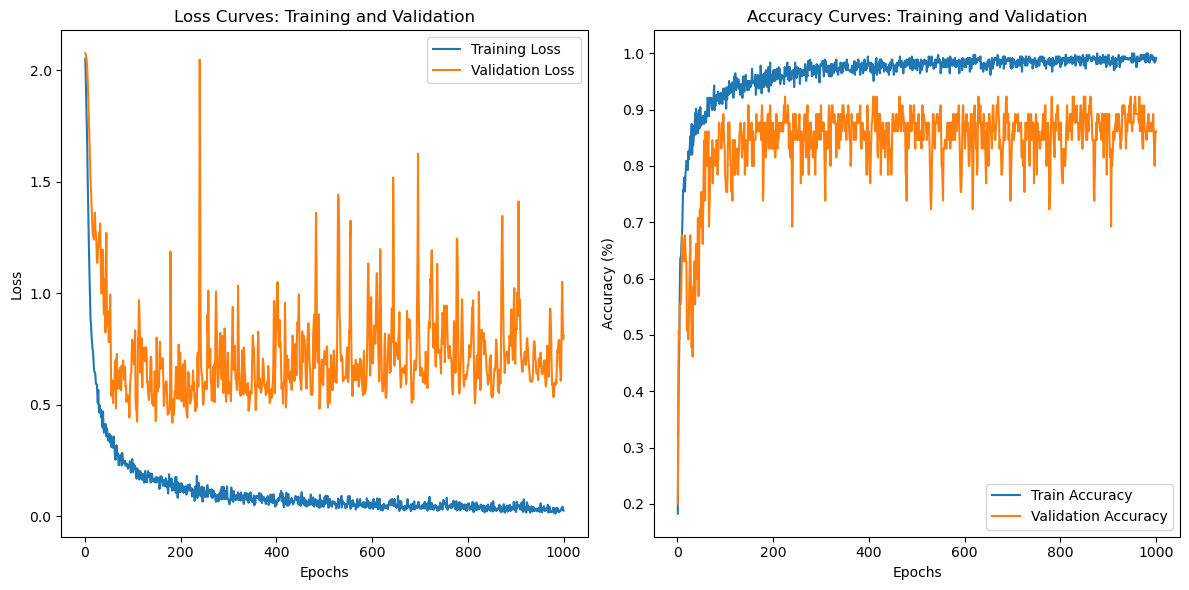

Test User 2 Finished: Accuracy=0.6458, Recall=0.6458, F1=0.6473
--------------------------------------------------
Processando Usuário 3
Train Users: [1, 2, 4, 5, 6, 7, 8, 9, 10]
0
Generating reference for frequency index 0, frequency 8.0 Hz
Y_train shape after freq 8.0 Hz: (13500, 6, 8)
Y_test shape after freq 8.0 Hz: (1500, 6, 8)
1
Generating reference for frequency index 1, frequency 9.0 Hz
Y_train shape after freq 9.0 Hz: (13500, 6, 8)
Y_test shape after freq 9.0 Hz: (1500, 6, 8)
2
Generating reference for frequency index 2, frequency 10.0 Hz
Y_train shape after freq 10.0 Hz: (13500, 6, 8)
Y_test shape after freq 10.0 Hz: (1500, 6, 8)
3
Generating reference for frequency index 3, frequency 11.0 Hz
Y_train shape after freq 11.0 Hz: (13500, 6, 8)
Y_test shape after freq 11.0 Hz: (1500, 6, 8)
4
Generating reference for frequency index 4, frequency 12.0 Hz
Y_train shape after freq 12.0 Hz: (13500, 6, 8)
Y_test shape after freq 12.0 Hz: (1500, 6, 8)
5
Generating reference for frequency 

/tmp/ipykernel_359974/3403985805.py:175: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_treino = torch.tensor(rotulos_treinamento, dtype=torch.long).to(device)
/tmp/ipykernel_359974/3403985805.py:176: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_teste = torch.tensor(rotulos_teste, dtype=torch.long).to(device)


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1/1000: Train Loss: 2.0634, Train Accuracy: 0.1444, Val Loss: 2.0774, Val Accuracy: 0.1846
Epoch 2/1000: Train Loss: 1.9898, Train Accuracy: 0.2807, Val Loss: 2.0726, Val Accuracy: 0.2154
Epoch 3/1000: Train Loss: 1.9220, Train Accuracy: 0.3515, Val Loss: 2.0647, Val Accuracy: 0.2308
Epoch 4/1000: Train Loss: 1.8461, Train Accuracy: 0.4632, Val Loss: 2.0512, Val Accuracy: 0.2462
Epoch 5/1000: Train Loss: 1.7655, Train Accuracy: 0.5123, Val Loss: 2.0305, Val Accuracy: 0.2308
Epoch 6/1000: Train Loss: 1.6631, Train Accuracy: 0.4932, Val Loss: 1.9995, Val Accuracy: 0.2615
Epoch 7/1000: Train Loss: 1.5797, Train Accuracy: 0.5368, Val Loss: 1.9575, Val Accuracy: 0.3385
Epoch 8/1000: Train Loss: 1.4586, Train Accuracy: 0.5804, Val Loss: 1.9075, Val Accuracy: 0.4000
Epoch 9/1000: Train Loss: 1.3033, Train Accuracy: 0.6294, Val Loss: 1.8437, Val Accuracy: 0.4769
Epoch 10/1000: Train Loss: 1.2279, Train Accuracy: 0.6185, Val Loss: 1.7652, Val Accuracy: 0.4769
Epoch 11/1000: Train Loss: 1.

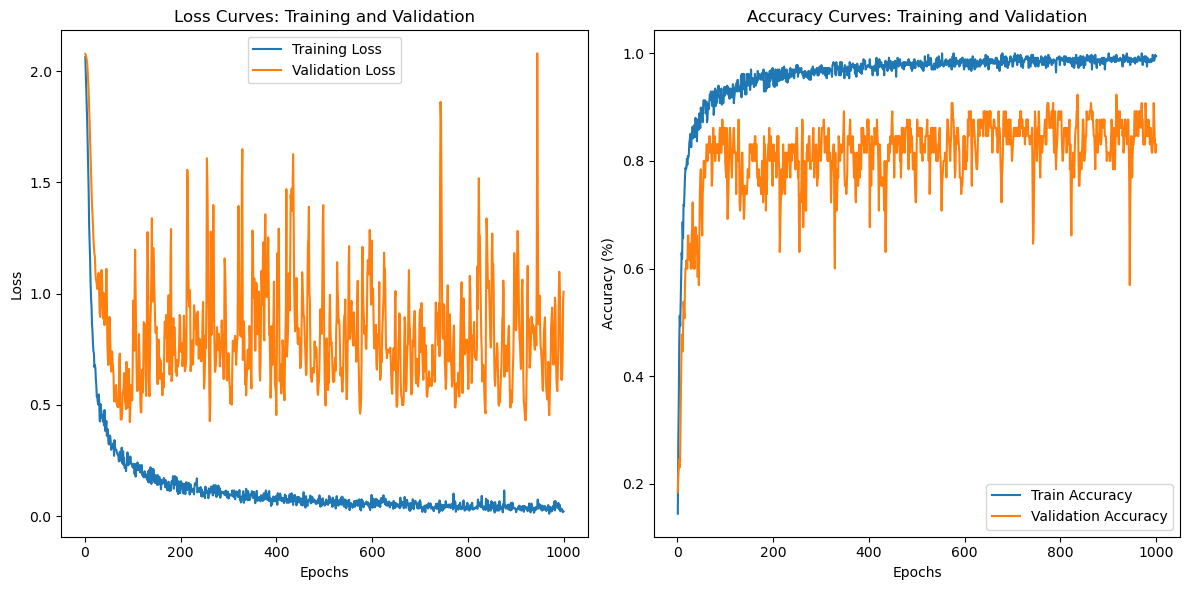

Test User 3 Finished: Accuracy=1.0000, Recall=1.0000, F1=1.0000
--------------------------------------------------
Processando Usuário 4
Train Users: [1, 2, 3, 5, 6, 7, 8, 9, 10]
0
Generating reference for frequency index 0, frequency 8.0 Hz
Y_train shape after freq 8.0 Hz: (13500, 6, 8)
Y_test shape after freq 8.0 Hz: (1500, 6, 8)
1
Generating reference for frequency index 1, frequency 9.0 Hz
Y_train shape after freq 9.0 Hz: (13500, 6, 8)
Y_test shape after freq 9.0 Hz: (1500, 6, 8)
2
Generating reference for frequency index 2, frequency 10.0 Hz
Y_train shape after freq 10.0 Hz: (13500, 6, 8)
Y_test shape after freq 10.0 Hz: (1500, 6, 8)
3
Generating reference for frequency index 3, frequency 11.0 Hz
Y_train shape after freq 11.0 Hz: (13500, 6, 8)
Y_test shape after freq 11.0 Hz: (1500, 6, 8)
4
Generating reference for frequency index 4, frequency 12.0 Hz
Y_train shape after freq 12.0 Hz: (13500, 6, 8)
Y_test shape after freq 12.0 Hz: (1500, 6, 8)
5
Generating reference for frequency 

/tmp/ipykernel_359974/3403985805.py:175: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_treino = torch.tensor(rotulos_treinamento, dtype=torch.long).to(device)
/tmp/ipykernel_359974/3403985805.py:176: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_teste = torch.tensor(rotulos_teste, dtype=torch.long).to(device)


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1/1000: Train Loss: 2.0508, Train Accuracy: 0.1826, Val Loss: 2.0732, Val Accuracy: 0.3385
Epoch 2/1000: Train Loss: 1.9410, Train Accuracy: 0.3896, Val Loss: 2.0630, Val Accuracy: 0.4923
Epoch 3/1000: Train Loss: 1.8494, Train Accuracy: 0.5095, Val Loss: 2.0448, Val Accuracy: 0.5538
Epoch 4/1000: Train Loss: 1.7715, Train Accuracy: 0.5531, Val Loss: 2.0172, Val Accuracy: 0.5692
Epoch 5/1000: Train Loss: 1.6418, Train Accuracy: 0.6267, Val Loss: 1.9793, Val Accuracy: 0.5692
Epoch 6/1000: Train Loss: 1.5232, Train Accuracy: 0.6431, Val Loss: 1.9326, Val Accuracy: 0.6154
Epoch 7/1000: Train Loss: 1.4239, Train Accuracy: 0.6676, Val Loss: 1.8745, Val Accuracy: 0.6615
Epoch 8/1000: Train Loss: 1.3083, Train Accuracy: 0.6676, Val Loss: 1.7996, Val Accuracy: 0.6923
Epoch 9/1000: Train Loss: 1.1662, Train Accuracy: 0.7166, Val Loss: 1.7070, Val Accuracy: 0.7077
Epoch 10/1000: Train Loss: 1.0327, Train Accuracy: 0.7766, Val Loss: 1.6111, Val Accuracy: 0.6308
Epoch 11/1000: Train Loss: 0.

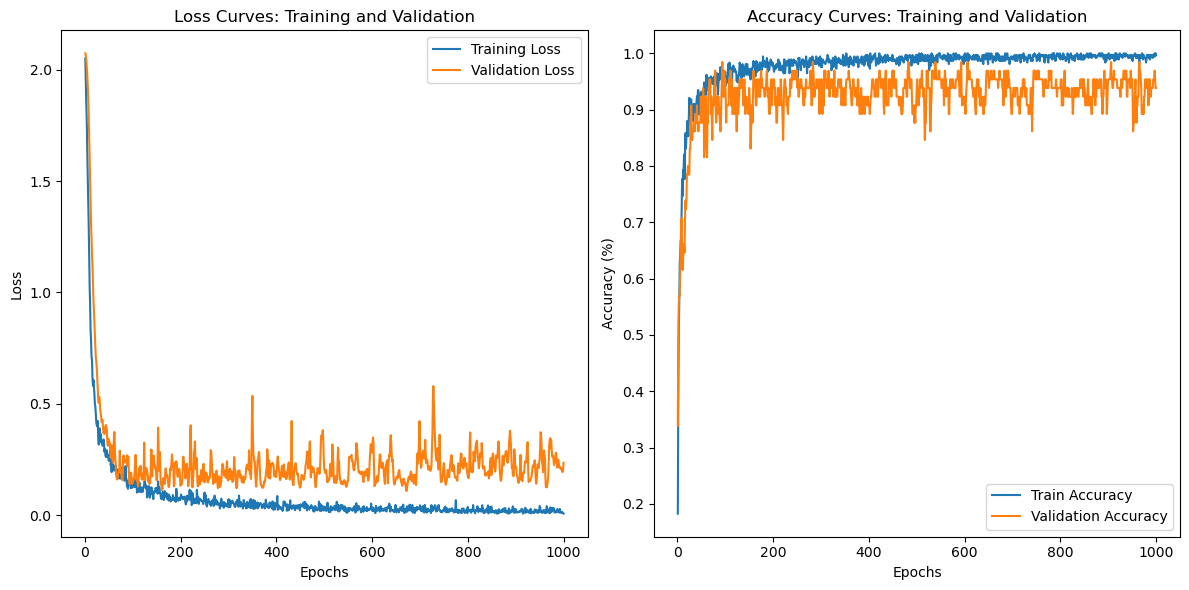

Test User 4 Finished: Accuracy=0.3125, Recall=0.3125, F1=0.2797
--------------------------------------------------
Processando Usuário 5
Train Users: [1, 2, 3, 4, 6, 7, 8, 9, 10]
0
Generating reference for frequency index 0, frequency 8.0 Hz
Y_train shape after freq 8.0 Hz: (13500, 6, 8)
Y_test shape after freq 8.0 Hz: (1500, 6, 8)
1
Generating reference for frequency index 1, frequency 9.0 Hz
Y_train shape after freq 9.0 Hz: (13500, 6, 8)
Y_test shape after freq 9.0 Hz: (1500, 6, 8)
2
Generating reference for frequency index 2, frequency 10.0 Hz
Y_train shape after freq 10.0 Hz: (13500, 6, 8)
Y_test shape after freq 10.0 Hz: (1500, 6, 8)
3
Generating reference for frequency index 3, frequency 11.0 Hz
Y_train shape after freq 11.0 Hz: (13500, 6, 8)
Y_test shape after freq 11.0 Hz: (1500, 6, 8)
4
Generating reference for frequency index 4, frequency 12.0 Hz
Y_train shape after freq 12.0 Hz: (13500, 6, 8)
Y_test shape after freq 12.0 Hz: (1500, 6, 8)
5
Generating reference for frequency 

/tmp/ipykernel_359974/3403985805.py:175: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_treino = torch.tensor(rotulos_treinamento, dtype=torch.long).to(device)
/tmp/ipykernel_359974/3403985805.py:176: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_teste = torch.tensor(rotulos_teste, dtype=torch.long).to(device)


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1/1000: Train Loss: 2.0577, Train Accuracy: 0.1662, Val Loss: 2.0760, Val Accuracy: 0.1077
Epoch 2/1000: Train Loss: 1.9629, Train Accuracy: 0.3460, Val Loss: 2.0724, Val Accuracy: 0.2000
Epoch 3/1000: Train Loss: 1.9029, Train Accuracy: 0.4332, Val Loss: 2.0650, Val Accuracy: 0.2615
Epoch 4/1000: Train Loss: 1.8227, Train Accuracy: 0.4823, Val Loss: 2.0505, Val Accuracy: 0.3077
Epoch 5/1000: Train Loss: 1.7209, Train Accuracy: 0.5586, Val Loss: 2.0272, Val Accuracy: 0.3692
Epoch 6/1000: Train Loss: 1.6301, Train Accuracy: 0.5395, Val Loss: 1.9926, Val Accuracy: 0.4462
Epoch 7/1000: Train Loss: 1.5249, Train Accuracy: 0.5668, Val Loss: 1.9479, Val Accuracy: 0.5385
Epoch 8/1000: Train Loss: 1.4247, Train Accuracy: 0.5940, Val Loss: 1.8968, Val Accuracy: 0.5231
Epoch 9/1000: Train Loss: 1.3099, Train Accuracy: 0.6267, Val Loss: 1.8384, Val Accuracy: 0.5538
Epoch 10/1000: Train Loss: 1.2016, Train Accuracy: 0.6948, Val Loss: 1.7803, Val Accuracy: 0.5231
Epoch 11/1000: Train Loss: 1.

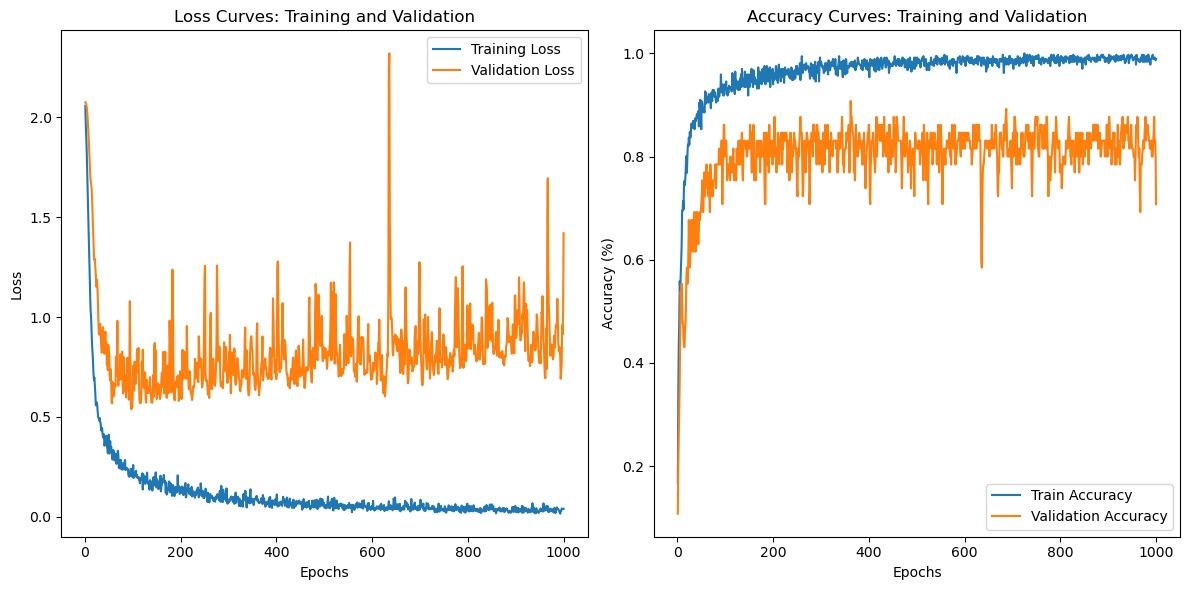

Test User 5 Finished: Accuracy=0.8750, Recall=0.8750, F1=0.8740
--------------------------------------------------
Processando Usuário 6
Train Users: [1, 2, 3, 4, 5, 7, 8, 9, 10]
0
Generating reference for frequency index 0, frequency 8.0 Hz
Y_train shape after freq 8.0 Hz: (13500, 6, 8)
Y_test shape after freq 8.0 Hz: (1500, 6, 8)
1
Generating reference for frequency index 1, frequency 9.0 Hz
Y_train shape after freq 9.0 Hz: (13500, 6, 8)
Y_test shape after freq 9.0 Hz: (1500, 6, 8)
2
Generating reference for frequency index 2, frequency 10.0 Hz
Y_train shape after freq 10.0 Hz: (13500, 6, 8)
Y_test shape after freq 10.0 Hz: (1500, 6, 8)
3
Generating reference for frequency index 3, frequency 11.0 Hz
Y_train shape after freq 11.0 Hz: (13500, 6, 8)
Y_test shape after freq 11.0 Hz: (1500, 6, 8)
4
Generating reference for frequency index 4, frequency 12.0 Hz
Y_train shape after freq 12.0 Hz: (13500, 6, 8)
Y_test shape after freq 12.0 Hz: (1500, 6, 8)
5
Generating reference for frequency 

/tmp/ipykernel_359974/3403985805.py:175: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_treino = torch.tensor(rotulos_treinamento, dtype=torch.long).to(device)
/tmp/ipykernel_359974/3403985805.py:176: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_teste = torch.tensor(rotulos_teste, dtype=torch.long).to(device)


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1/1000: Train Loss: 2.0733, Train Accuracy: 0.1662, Val Loss: 2.0780, Val Accuracy: 0.1538
Epoch 2/1000: Train Loss: 2.0094, Train Accuracy: 0.2834, Val Loss: 2.0759, Val Accuracy: 0.3077
Epoch 3/1000: Train Loss: 1.9460, Train Accuracy: 0.4005, Val Loss: 2.0714, Val Accuracy: 0.4308
Epoch 4/1000: Train Loss: 1.8751, Train Accuracy: 0.4496, Val Loss: 2.0630, Val Accuracy: 0.4462
Epoch 5/1000: Train Loss: 1.7861, Train Accuracy: 0.5559, Val Loss: 2.0499, Val Accuracy: 0.4000
Epoch 6/1000: Train Loss: 1.7089, Train Accuracy: 0.5749, Val Loss: 2.0315, Val Accuracy: 0.4000
Epoch 7/1000: Train Loss: 1.5653, Train Accuracy: 0.6349, Val Loss: 2.0070, Val Accuracy: 0.4154
Epoch 8/1000: Train Loss: 1.4415, Train Accuracy: 0.6294, Val Loss: 1.9681, Val Accuracy: 0.4000
Epoch 9/1000: Train Loss: 1.3253, Train Accuracy: 0.6376, Val Loss: 1.9141, Val Accuracy: 0.4000
Epoch 10/1000: Train Loss: 1.1691, Train Accuracy: 0.7003, Val Loss: 1.8493, Val Accuracy: 0.4462
Epoch 11/1000: Train Loss: 1.

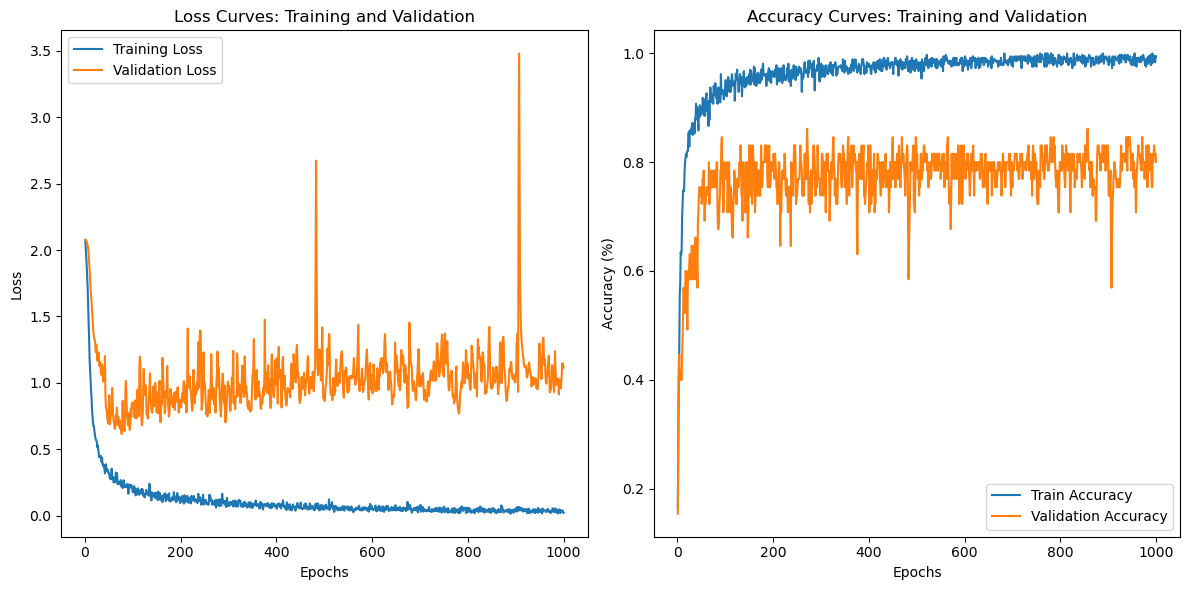

Test User 6 Finished: Accuracy=0.8125, Recall=0.8125, F1=0.8091
--------------------------------------------------
Processando Usuário 7
Train Users: [1, 2, 3, 4, 5, 6, 8, 9, 10]
0
Generating reference for frequency index 0, frequency 8.0 Hz
Y_train shape after freq 8.0 Hz: (13500, 6, 8)
Y_test shape after freq 8.0 Hz: (1500, 6, 8)
1
Generating reference for frequency index 1, frequency 9.0 Hz
Y_train shape after freq 9.0 Hz: (13500, 6, 8)
Y_test shape after freq 9.0 Hz: (1500, 6, 8)
2
Generating reference for frequency index 2, frequency 10.0 Hz
Y_train shape after freq 10.0 Hz: (13500, 6, 8)
Y_test shape after freq 10.0 Hz: (1500, 6, 8)
3
Generating reference for frequency index 3, frequency 11.0 Hz
Y_train shape after freq 11.0 Hz: (13500, 6, 8)
Y_test shape after freq 11.0 Hz: (1500, 6, 8)
4
Generating reference for frequency index 4, frequency 12.0 Hz
Y_train shape after freq 12.0 Hz: (13500, 6, 8)
Y_test shape after freq 12.0 Hz: (1500, 6, 8)
5
Generating reference for frequency 

/tmp/ipykernel_359974/3403985805.py:175: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_treino = torch.tensor(rotulos_treinamento, dtype=torch.long).to(device)
/tmp/ipykernel_359974/3403985805.py:176: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_teste = torch.tensor(rotulos_teste, dtype=torch.long).to(device)


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1/1000: Train Loss: 2.0797, Train Accuracy: 0.1335, Val Loss: 2.0768, Val Accuracy: 0.2462
Epoch 2/1000: Train Loss: 1.9825, Train Accuracy: 0.2643, Val Loss: 2.0726, Val Accuracy: 0.2923
Epoch 3/1000: Train Loss: 1.9003, Train Accuracy: 0.4005, Val Loss: 2.0657, Val Accuracy: 0.3692
Epoch 4/1000: Train Loss: 1.8273, Train Accuracy: 0.4632, Val Loss: 2.0528, Val Accuracy: 0.4308
Epoch 5/1000: Train Loss: 1.7108, Train Accuracy: 0.5150, Val Loss: 2.0286, Val Accuracy: 0.4615
Epoch 6/1000: Train Loss: 1.6112, Train Accuracy: 0.5531, Val Loss: 1.9917, Val Accuracy: 0.4154
Epoch 7/1000: Train Loss: 1.5030, Train Accuracy: 0.5504, Val Loss: 1.9421, Val Accuracy: 0.3846
Epoch 8/1000: Train Loss: 1.4068, Train Accuracy: 0.5967, Val Loss: 1.8833, Val Accuracy: 0.4000
Epoch 9/1000: Train Loss: 1.3221, Train Accuracy: 0.5940, Val Loss: 1.8280, Val Accuracy: 0.4000
Epoch 10/1000: Train Loss: 1.2520, Train Accuracy: 0.6322, Val Loss: 1.7748, Val Accuracy: 0.4308
Epoch 11/1000: Train Loss: 1.

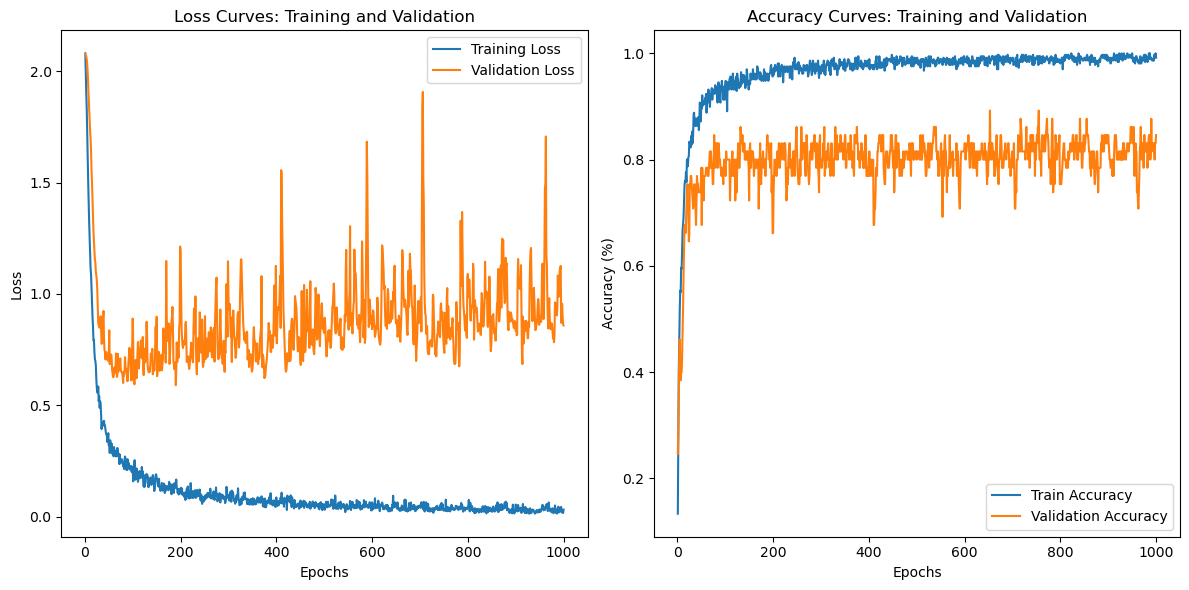

Test User 7 Finished: Accuracy=0.7708, Recall=0.7708, F1=0.7626
--------------------------------------------------
Processando Usuário 8
Train Users: [1, 2, 3, 4, 5, 6, 7, 9, 10]
0
Generating reference for frequency index 0, frequency 8.0 Hz
Y_train shape after freq 8.0 Hz: (13500, 6, 8)
Y_test shape after freq 8.0 Hz: (1500, 6, 8)
1
Generating reference for frequency index 1, frequency 9.0 Hz
Y_train shape after freq 9.0 Hz: (13500, 6, 8)
Y_test shape after freq 9.0 Hz: (1500, 6, 8)
2
Generating reference for frequency index 2, frequency 10.0 Hz
Y_train shape after freq 10.0 Hz: (13500, 6, 8)
Y_test shape after freq 10.0 Hz: (1500, 6, 8)
3
Generating reference for frequency index 3, frequency 11.0 Hz
Y_train shape after freq 11.0 Hz: (13500, 6, 8)
Y_test shape after freq 11.0 Hz: (1500, 6, 8)
4
Generating reference for frequency index 4, frequency 12.0 Hz
Y_train shape after freq 12.0 Hz: (13500, 6, 8)
Y_test shape after freq 12.0 Hz: (1500, 6, 8)
5
Generating reference for frequency 

/tmp/ipykernel_359974/3403985805.py:175: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_treino = torch.tensor(rotulos_treinamento, dtype=torch.long).to(device)
/tmp/ipykernel_359974/3403985805.py:176: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_teste = torch.tensor(rotulos_teste, dtype=torch.long).to(device)


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1/1000: Train Loss: 2.0513, Train Accuracy: 0.1880, Val Loss: 2.0743, Val Accuracy: 0.2000
Epoch 2/1000: Train Loss: 1.9562, Train Accuracy: 0.3651, Val Loss: 2.0699, Val Accuracy: 0.1846
Epoch 3/1000: Train Loss: 1.8554, Train Accuracy: 0.4796, Val Loss: 2.0620, Val Accuracy: 0.3231
Epoch 4/1000: Train Loss: 1.7524, Train Accuracy: 0.5341, Val Loss: 2.0481, Val Accuracy: 0.3077
Epoch 5/1000: Train Loss: 1.6385, Train Accuracy: 0.6049, Val Loss: 2.0284, Val Accuracy: 0.2769
Epoch 6/1000: Train Loss: 1.5395, Train Accuracy: 0.5777, Val Loss: 1.9992, Val Accuracy: 0.3385
Epoch 7/1000: Train Loss: 1.4318, Train Accuracy: 0.5995, Val Loss: 1.9580, Val Accuracy: 0.3846
Epoch 8/1000: Train Loss: 1.3036, Train Accuracy: 0.6431, Val Loss: 1.9046, Val Accuracy: 0.4154
Epoch 9/1000: Train Loss: 1.1960, Train Accuracy: 0.7057, Val Loss: 1.8399, Val Accuracy: 0.4462
Epoch 10/1000: Train Loss: 1.1541, Train Accuracy: 0.7003, Val Loss: 1.7704, Val Accuracy: 0.4462
Epoch 11/1000: Train Loss: 1.

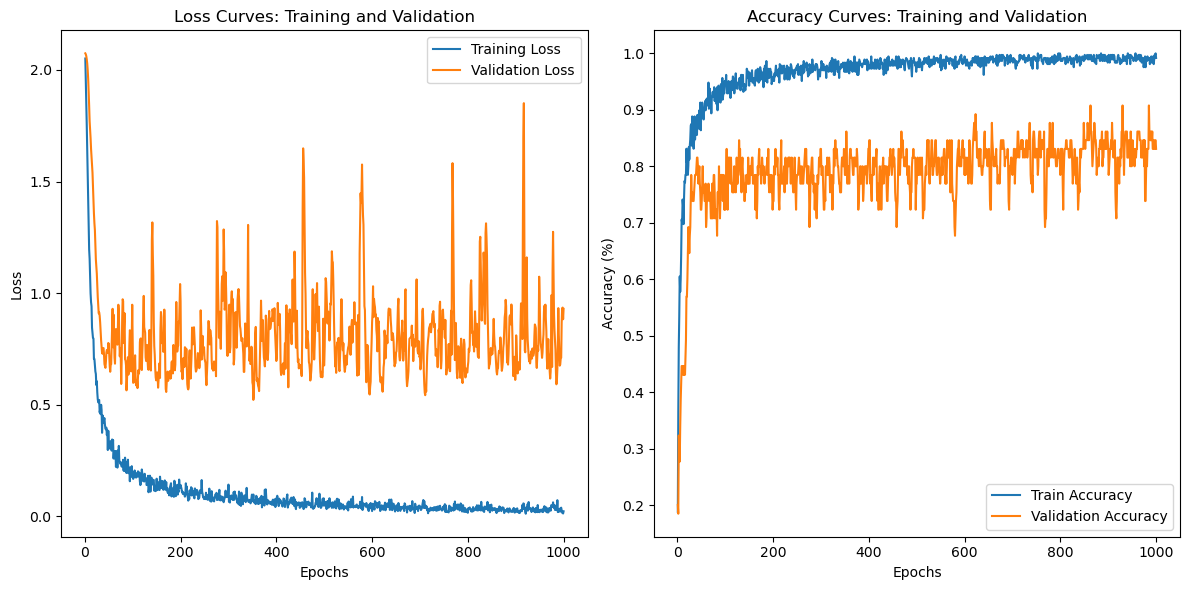

Test User 8 Finished: Accuracy=0.8125, Recall=0.8125, F1=0.8071
--------------------------------------------------
Processando Usuário 9
Train Users: [1, 2, 3, 4, 5, 6, 7, 8, 10]
0
Generating reference for frequency index 0, frequency 8.0 Hz
Y_train shape after freq 8.0 Hz: (13500, 6, 8)
Y_test shape after freq 8.0 Hz: (1500, 6, 8)
1
Generating reference for frequency index 1, frequency 9.0 Hz
Y_train shape after freq 9.0 Hz: (13500, 6, 8)
Y_test shape after freq 9.0 Hz: (1500, 6, 8)
2
Generating reference for frequency index 2, frequency 10.0 Hz
Y_train shape after freq 10.0 Hz: (13500, 6, 8)
Y_test shape after freq 10.0 Hz: (1500, 6, 8)
3
Generating reference for frequency index 3, frequency 11.0 Hz
Y_train shape after freq 11.0 Hz: (13500, 6, 8)
Y_test shape after freq 11.0 Hz: (1500, 6, 8)
4
Generating reference for frequency index 4, frequency 12.0 Hz
Y_train shape after freq 12.0 Hz: (13500, 6, 8)
Y_test shape after freq 12.0 Hz: (1500, 6, 8)
5
Generating reference for frequency 

/tmp/ipykernel_359974/3403985805.py:175: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_treino = torch.tensor(rotulos_treinamento, dtype=torch.long).to(device)
/tmp/ipykernel_359974/3403985805.py:176: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_teste = torch.tensor(rotulos_teste, dtype=torch.long).to(device)


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1/1000: Train Loss: 2.0681, Train Accuracy: 0.1417, Val Loss: 2.0764, Val Accuracy: 0.2462
Epoch 2/1000: Train Loss: 1.9735, Train Accuracy: 0.3324, Val Loss: 2.0728, Val Accuracy: 0.3231
Epoch 3/1000: Train Loss: 1.8870, Train Accuracy: 0.4414, Val Loss: 2.0654, Val Accuracy: 0.3692
Epoch 4/1000: Train Loss: 1.7953, Train Accuracy: 0.5068, Val Loss: 2.0524, Val Accuracy: 0.4615
Epoch 5/1000: Train Loss: 1.6776, Train Accuracy: 0.5722, Val Loss: 2.0319, Val Accuracy: 0.4462
Epoch 6/1000: Train Loss: 1.5682, Train Accuracy: 0.6049, Val Loss: 2.0012, Val Accuracy: 0.4615
Epoch 7/1000: Train Loss: 1.4760, Train Accuracy: 0.6376, Val Loss: 1.9600, Val Accuracy: 0.4923
Epoch 8/1000: Train Loss: 1.3550, Train Accuracy: 0.6512, Val Loss: 1.9081, Val Accuracy: 0.4923
Epoch 9/1000: Train Loss: 1.2478, Train Accuracy: 0.6948, Val Loss: 1.8471, Val Accuracy: 0.4923
Epoch 10/1000: Train Loss: 1.1589, Train Accuracy: 0.6921, Val Loss: 1.7833, Val Accuracy: 0.5077
Epoch 11/1000: Train Loss: 1.

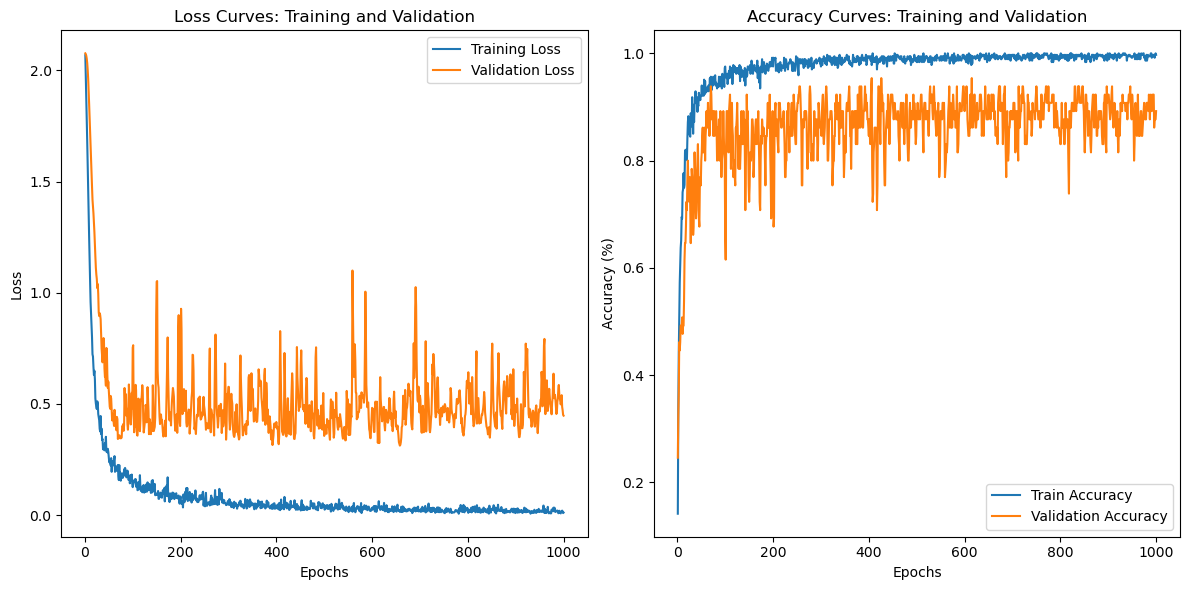

Test User 9 Finished: Accuracy=0.4583, Recall=0.4583, F1=0.4246
--------------------------------------------------
Processando Usuário 10
Train Users: [1, 2, 3, 4, 5, 6, 7, 8, 9]
0
Generating reference for frequency index 0, frequency 8.0 Hz
Y_train shape after freq 8.0 Hz: (13500, 6, 8)
Y_test shape after freq 8.0 Hz: (1500, 6, 8)
1
Generating reference for frequency index 1, frequency 9.0 Hz
Y_train shape after freq 9.0 Hz: (13500, 6, 8)
Y_test shape after freq 9.0 Hz: (1500, 6, 8)
2
Generating reference for frequency index 2, frequency 10.0 Hz
Y_train shape after freq 10.0 Hz: (13500, 6, 8)
Y_test shape after freq 10.0 Hz: (1500, 6, 8)
3
Generating reference for frequency index 3, frequency 11.0 Hz
Y_train shape after freq 11.0 Hz: (13500, 6, 8)
Y_test shape after freq 11.0 Hz: (1500, 6, 8)
4
Generating reference for frequency index 4, frequency 12.0 Hz
Y_train shape after freq 12.0 Hz: (13500, 6, 8)
Y_test shape after freq 12.0 Hz: (1500, 6, 8)
5
Generating reference for frequency 

/tmp/ipykernel_359974/3403985805.py:175: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_treino = torch.tensor(rotulos_treinamento, dtype=torch.long).to(device)
/tmp/ipykernel_359974/3403985805.py:176: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_teste = torch.tensor(rotulos_teste, dtype=torch.long).to(device)


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1/1000: Train Loss: 2.0642, Train Accuracy: 0.1771, Val Loss: 2.0797, Val Accuracy: 0.2154
Epoch 2/1000: Train Loss: 1.9831, Train Accuracy: 0.3379, Val Loss: 2.0766, Val Accuracy: 0.2462
Epoch 3/1000: Train Loss: 1.8920, Train Accuracy: 0.4414, Val Loss: 2.0692, Val Accuracy: 0.2923
Epoch 4/1000: Train Loss: 1.8108, Train Accuracy: 0.5150, Val Loss: 2.0578, Val Accuracy: 0.3231
Epoch 5/1000: Train Loss: 1.7367, Train Accuracy: 0.5504, Val Loss: 2.0399, Val Accuracy: 0.3385
Epoch 6/1000: Train Loss: 1.6472, Train Accuracy: 0.5858, Val Loss: 2.0136, Val Accuracy: 0.3077
Epoch 7/1000: Train Loss: 1.5582, Train Accuracy: 0.6104, Val Loss: 1.9852, Val Accuracy: 0.3692
Epoch 8/1000: Train Loss: 1.4735, Train Accuracy: 0.6022, Val Loss: 1.9555, Val Accuracy: 0.3385
Epoch 9/1000: Train Loss: 1.3512, Train Accuracy: 0.6349, Val Loss: 1.9243, Val Accuracy: 0.3077
Epoch 10/1000: Train Loss: 1.2588, Train Accuracy: 0.6567, Val Loss: 1.8940, Val Accuracy: 0.3385
Epoch 11/1000: Train Loss: 1.

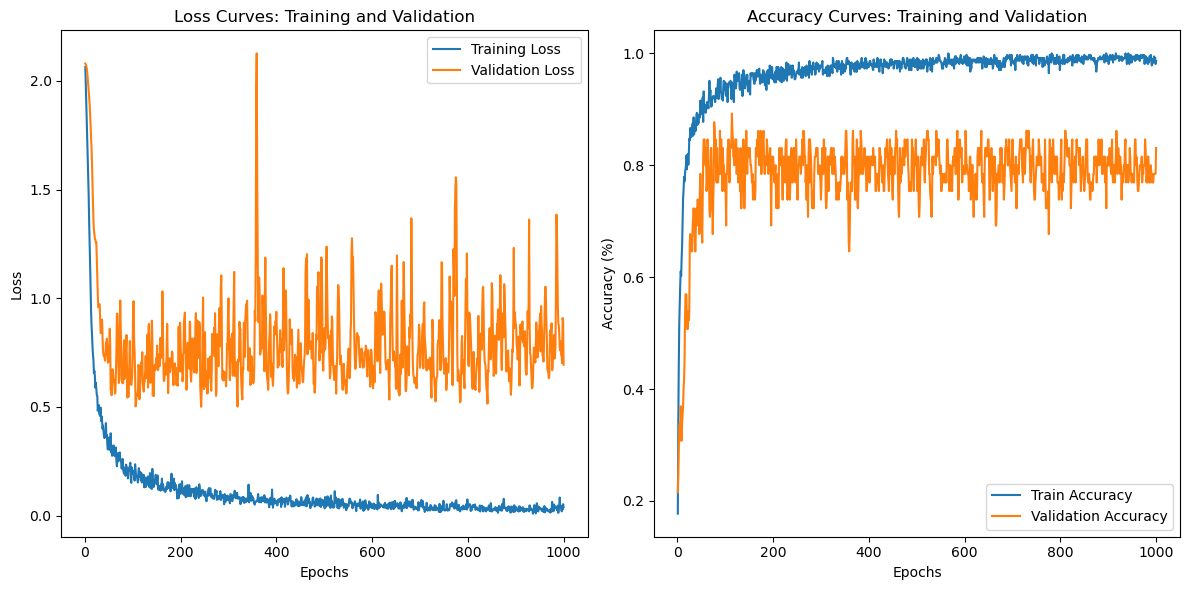

Test User 10 Finished: Accuracy=0.8542, Recall=0.8542, F1=0.8248
--------------------------------------------------


In [14]:
seed = 42
torch.cuda.manual_seed(seed)
torch.manual_seed(seed)

# Cross-Subject EEGNet Training (single window per trial, no window separation)
metricas_usuarios = []
exp_dir.mkdir(parents=True, exist_ok=True)

# Prepare cross-subject splits
for test_user_idx, test_user in enumerate(users):
    print(f"Processando Usuário {test_user}")
    train_users = [u for u in users if u != test_user]
    print(f"Train Users: {train_users}")

    # Concatenate training data from all train_users
    train_data = np.concatenate(
        [all_data[users.index(u)] for u in train_users], axis=-1
    )  # shape: (channels, samples, freqs, trials)
    test_data = all_data[test_user_idx]

    num_canais, _, num_freqs, num_trials_train = train_data.shape
    num_trials_test = test_data.shape[-1]

    # Prepare reference matrices for all frequencies (no window separation)
    Y_train = np.zeros(
        (tamanho_da_janela * num_trials_train, num_harmonica * 2, len(indices))
    )
    Y_test = np.zeros(
        (tamanho_da_janela * num_trials_test, num_harmonica * 2, len(indices))
    )
    for k in indices:
        print(k)
        print(
            f"Generating reference for frequency index {k}, frequency {frequencias[k]} Hz"
        )
        y_train = reference_matrix(
            num_harmonica,
            inform_fase,
            num_trials_train,
            frequencias[k],
            fases,
            tamanho_da_janela,
        )
        Y_train[:, :, k] = y_train.T
        print(f"Y_train shape after freq {frequencias[k]} Hz: {Y_train.shape}")
        y_test = reference_matrix(
            num_harmonica,
            inform_fase,
            num_trials_test,
            frequencias[k],
            fases,
            tamanho_da_janela,
        )
        Y_test[:, :, k] = y_test.T
        print(f"Y_test shape after freq {frequencias[k]} Hz: {Y_test.shape}")

    X_train = np.zeros(
        (tamanho_da_janela * num_trials_train, len(occipital_electrodes), len(indices))
    )
    X_test = np.zeros(
        (tamanho_da_janela * num_trials_test, len(occipital_electrodes), len(indices))
    )

    for k in range(len(indices)):
        # For training: each trial is a single window
        eeg_matrix_train = train_data[
            occipital_electrodes, :tamanho_da_janela, indices[k], :
        ]
        eeg_matrix_test = test_data[
            occipital_electrodes, :tamanho_da_janela, indices[k], :
        ]
        # Transpõe os dados para que cada linha represente uma amostra
        eeg_matrix_train = np.transpose(eeg_matrix_train)
        eeg_matrix_test = np.transpose(eeg_matrix_test)
        eeg_matrix_train = np.concatenate(eeg_matrix_train, axis=0)
        eeg_matrix_test = np.concatenate(eeg_matrix_test, axis=0)

        X_train[:, :, k] = eeg_matrix_train
        X_test[:, :, k] = eeg_matrix_test

    # CCA optimization (across all training data)
    Combinadores_Y = []
    Combinadores_X = []
    correlacoes_max = []
    for k in range(len(indices)):
        Wx, Wy, corr = CCA(X_train[:, :, k].T, Y_train[:, :, k].T)
        Combinadores_Y.append(Wy)
        Combinadores_X.append(Wx)
        correlacoes_max.append(corr)
    Combinadores_X = np.column_stack(Combinadores_X)
    Combinadores_Y = np.column_stack(Combinadores_Y)

    # Separar em janelas
    X_teste_janelas = []
    X_treino_janelas = []
    Y_teste_janelas = []
    Y_treino_janelas = []

    for k in range(len(indices)):
        X_t, numero_janelas_teste = get_windows(
            X_test[:, :, k], tamanho_da_janela, include_last=False
        )
        Y_t, _ = get_windows(Y_test[:, :, k], tamanho_da_janela, include_last=False)

        X_v, numero_janelas_treino = get_windows(
            X_train[:, :, k], tamanho_da_janela, include_last=False
        )
        Y_v, _ = get_windows(Y_train[:, :, k], tamanho_da_janela, include_last=False)

        X_teste_janelas.append(X_t)
        Y_teste_janelas.append(Y_t)

        X_treino_janelas.append(X_v)
        Y_treino_janelas.append(Y_v)

    # Construir tensor de treinamento
    rotulos_treinamento = []
    tensor_treinamento = np.zeros(
        [len(indices) * num_trials_train, len(indices), tamanho_da_janela]
    )
    cont = 0

    for m in range(len(indices)):
        for j in range(numero_janelas_treino):
            janela_x = X_treino_janelas[m][j]
            rotulos_treinamento.append(frequencias[indices[m]])
            cont_1 = 0
            for w in range(len(indices)):
                Wx = Combinadores_X[:, w]

                projecao_x = np.dot(Wx, janela_x.T)
                tensor_treinamento[cont, cont_1, :] = projecao_x

                cont_1 += 1
            cont += 1

    rotulos_teste = []
    tensor_teste = np.zeros(
        [len(indices) * num_trials_test, len(indices), tamanho_da_janela]
    )
    cont = 0

    for m in range(len(indices)):
        for j in range(numero_janelas_teste):
            janela_x = X_teste_janelas[m][j]
            rotulos_teste.append(frequencias[indices[m]])
            cont_1 = 0

            for w in range(len(indices)):
                Wx = Combinadores_X[:, w]

                projecao_x = np.dot(Wx, janela_x.T)
                tensor_teste[cont, cont_1, :] = projecao_x

                cont_1 += 1
            cont += 1

    # Map labels to indices
    mapeamento = {rotulo: i for i, rotulo in enumerate(sorted(frequencias_desejadas))}
    rotulos_treinamento = torch.tensor(
        [
            mapeamento[rotulo.item()] if hasattr(rotulo, "item") else mapeamento[rotulo]
            for rotulo in rotulos_treinamento
        ]
    )
    rotulos_teste = torch.tensor(
        [
            mapeamento[rotulo.item()] if hasattr(rotulo, "item") else mapeamento[rotulo]
            for rotulo in rotulos_teste
        ]
    )

    X_treino = torch.tensor(tensor_treinamento, dtype=torch.float32).to(device)
    X_teste = torch.tensor(tensor_teste, dtype=torch.float32).to(device)
    Y_treino = torch.tensor(rotulos_treinamento, dtype=torch.long).to(device)
    Y_teste = torch.tensor(rotulos_teste, dtype=torch.long).to(device)
    print("X_train:", X_treino.shape)
    print("X_test:", X_teste.shape)
    print("Y_train:", Y_treino.shape)
    print("Y_test:", Y_teste.shape)

    # Model setup
    model = EEGNet(
        n_chans=len(indices),  # Number of CCA components (same as number of frequencies)
        n_outputs=len(frequencias_desejadas),
        n_times=tamanho_da_janela,
        kernel_length=(sample_rate // 2),
        F1=8,
        D=2,
        drop_prob=0.25
    )

    model = model.to(device)
    criterion = torch.nn.CrossEntropyLoss()
    # optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
    optimizer = torch.optim.Adam(model.parameters(), lr=2.36e-3, weight_decay=2.42e-5)

    dataset = TensorDataset(X_treino, Y_treino)
    train_size = int(0.85 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(
        dataset, [train_size, val_size], generator=torch.Generator().manual_seed(seed)
    )
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
    test_loader = DataLoader(
        TensorDataset(X_teste, Y_teste), batch_size=10, shuffle=False
    )

    # Train
    best_model = train(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        num_epochs=epochs,
        device=device,
        save_path=exp_dir.joinpath(f"best_model_user_{test_user}.pth"),
    )

    # Evaluate
    accuracy, recall, f1, cm = evaluate(best_model, test_loader)

    metricas_usuarios.append(
        {
            "usuario": test_user,
            "acuracia": accuracy,
            "recall": recall,
            "f1-score": f1,
            "confusion_matrix": cm,
        }
    )
    print(
        f"Test User {test_user} Finished: Accuracy={accuracy:.4f}, Recall={recall:.4f}, F1={f1:.4f}"
    )

    # Salvar as métricas de cada usuário
    df_metricas = pd.DataFrame(metricas_usuarios)
    df_metricas.to_csv(exp_dir.joinpath("metricas.csv"), index=False)

    print("-" * 50)